# Computer Vision - Kelompok 7

### Library
---

In [1]:
import cv2
import os, zipfile
import numpy as np
import random
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import torch
from ultralytics import YOLO
from glob import glob

### Load Data
---

In [2]:
pothole_dir = "Pothole.v1i.yolov8"

def count_imgs(folder):
    return len(glob(os.path.join(folder, '*.jpg'))) + len(glob(os.path.join(folder, '*.png')))

train_count = count_imgs(os.path.join(pothole_dir, 'train', 'images'))
val_count   = count_imgs(os.path.join(pothole_dir, 'valid', 'images'))
test_count  = count_imgs(os.path.join(pothole_dir, 'test',  'images'))

print(f"Train : {train_count} Images")
print(f"Val   : {val_count} Images")
print(f"Test  : {test_count} Images")
print(f"Total : {train_count + val_count + test_count} Images")

Train : 1939 Images
Val   : 555 Images
Test  : 277 Images
Total : 2771 Images


### Data Preprocessing
---

Preprocessing Function

In [3]:
def preprocessing_new(img_path, output_img_dir, output_lbl_dir):
    file = os.path.basename(img_path)
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

    img = cv2.imread(img_path)
    if img is None:
        return
    if not os.path.exists(label_path):
        return
    with open(label_path, 'r') as f:
        label_lines = f.readlines()
    if not label_lines:
        return

    # Resize only — let YOLO handle all augmentation
    img_resized = cv2.resize(img, (640, 640))
    cv2.imwrite(os.path.join(output_img_dir, file), img_resized)
    with open(os.path.join(output_lbl_dir, file.replace('.jpg', '.txt')), 'w') as f:
        f.writelines(label_lines)

print("Preprocessing Function Ready.")

Preprocessing Function Ready.


Run Preprocessing on All Splits

In [4]:
print("Running preprocessing on all splits...")

for split in ['train', 'valid', 'test']:
    img_dir_split = os.path.join(pothole_dir, split, 'images')
    lbl_dir_split = os.path.join(pothole_dir, split, 'labels')

    all_imgs = glob(os.path.join(img_dir_split, '*.jpg')) +                glob(os.path.join(img_dir_split, '*.png'))
    print(f"   Preprocessing {split}: {len(all_imgs)} images...")

    for img_path in all_imgs:
        preprocessing_new(img_path, img_dir_split, lbl_dir_split)

print("\nPreprocessing Complete!")
print(f"Train : {len(glob(os.path.join(pothole_dir, 'train', 'images', '*.jpg')))} images")
print(f"Val   : {len(glob(os.path.join(pothole_dir, 'valid', 'images', '*.jpg')))} images")
print(f"Test  : {len(glob(os.path.join(pothole_dir, 'test',  'images', '*.jpg')))} images")

Running preprocessing on all splits...
   Preprocessing train: 1939 images...
   Preprocessing valid: 555 images...
   Preprocessing test: 277 images...

Preprocessing Complete!
Train : 1939 images
Val   : 555 images
Test  : 277 images


### Modelling - YOLOv8
---

Making File Configuration (data.yaml)

In [5]:
yaml_path = os.path.join(pothole_dir, 'data.yaml')

data_config = {
    'train': os.path.abspath(os.path.join(pothole_dir, 'train', 'images')),
    'val':   os.path.abspath(os.path.join(pothole_dir, 'valid', 'images')),
    'test':  os.path.abspath(os.path.join(pothole_dir, 'test',  'images')),
    'nc':    1,
    'names': ['pothole']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("data.yaml updated:")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml updated:
names:
- pothole
nc: 1
test: d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\Pothole.v1i.yolov8\test\images
train: d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\Pothole.v1i.yolov8\train\images
val: d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\Pothole.v1i.yolov8\valid\images



In [6]:
# # Jalankan di cell baru
# folders = glob('runs/detect/yolov8_pothole_kel7*')
# latest_folder = max(folders, key=os.path.getmtime)
# best_weight = os.path.join(latest_folder, 'weights', 'best.pt')

# check_model = YOLO(best_weight)

# test_images_dir = os.path.join(pothole_dir, 'test', 'images')
# all_test = [f for f in os.listdir(test_images_dir) if f.endswith('.jpg')]

# detected = 0
# not_detected = 0

# for img_name in all_test:
#     img_path = os.path.join(test_images_dir, img_name)
#     result = check_model(img_path, conf=0.25, verbose=False)[0]
#     if len(result.boxes) > 0:
#         detected += 1
#     else:
#         not_detected += 1

# print(f"Total test images  : {len(all_test)}")
# print(f"Gambar terdeteksi  : {detected}")
# print(f"Tidak terdeteksi   : {not_detected}")
# print(f"Detection rate     : {detected/len(all_test)*100:.1f}%")

Load YOLOv8 and Training Model

In [7]:
if os.path.exists('runs'):
    shutil.rmtree('runs')
torch.cuda.empty_cache()

model = YOLO('yolov8m.pt')

results = model.train(
    data=os.path.abspath(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=25,

    lr0=0.01,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,

    # Spatial augmentation — YOLO built-in
    mosaic=1.0,
    degrees=15.0,
    scale=0.6,
    fliplr=0.5,
    flipud=0.3,
    translate=0.1,

    name='yolov8_pothole_kel7'
)

Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\Pothole.v1i.yolov8\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo

### Evaluation Metric and Exporting Model
---

Total Loss and Accuracy Plotting

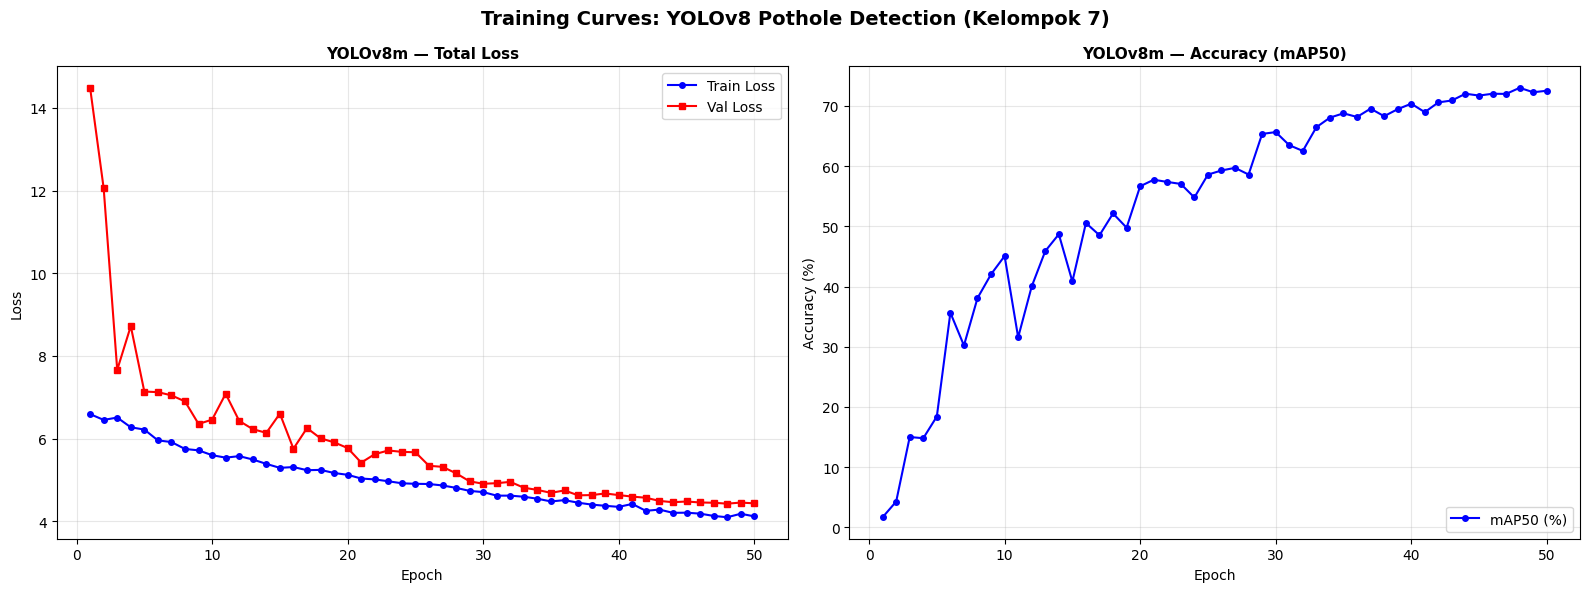

In [13]:
%matplotlib inline

folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    csv_path = os.path.join(latest_folder, 'results.csv')

    if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        epochs_col = df['epoch']

        train_total_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
        val_total_loss   = df['val/box_loss']   + df['val/cls_loss']   + df['val/dfl_loss']
        accuracy_map50   = df['metrics/mAP50(B)'] * 100

        # FIX: drop NaN rows from val loss (caused by close_mosaic final epochs)
        val_mask   = val_total_loss.notna()
        acc_mask   = accuracy_map50.notna()

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Training Curves: YOLOv8 Pothole Detection (Kelompok 7)',
                     fontweight='bold', fontsize=14)

        axes[0].plot(epochs_col,            train_total_loss,          'b-o', markersize=4, label='Train Loss')
        axes[0].plot(epochs_col[val_mask],  val_total_loss[val_mask],  'r-s', markersize=4, label='Val Loss')
        axes[0].set_title('YOLOv8m — Total Loss', fontweight='bold', fontsize=11)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs_col[acc_mask], accuracy_map50[acc_mask], 'b-o', markersize=4, label='mAP50 (%)')
        axes[1].set_title('YOLOv8m — Accuracy (mAP50)', fontweight='bold', fontsize=11)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].legend(loc='lower right')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("results.csv is empty or not found.")
else:
    print("No training folder found.")

Confusion Matrix

Loading Confusion Matrix from: runs/detect\yolov8_pothole_kel7


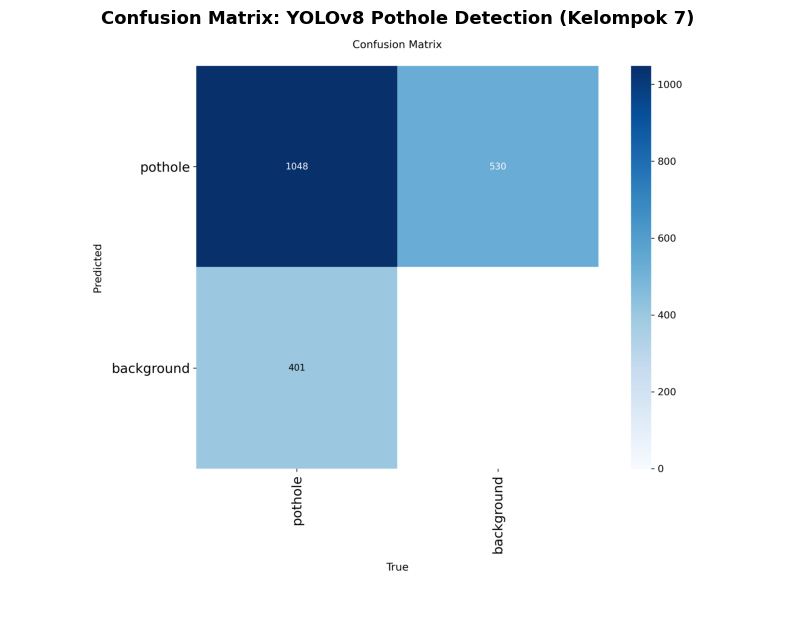

In [14]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    cm_path = os.path.join(latest_folder, 'confusion_matrix.png')

    if os.path.exists(cm_path):
        print(f"Loading Confusion Matrix from: {latest_folder}")

        img_bgr = cv2.imread(cm_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.title("Confusion Matrix: YOLOv8 Pothole Detection (Kelompok 7)",
                  fontweight='bold', fontsize=13)
        plt.axis('off')
        plt.show()
    else:
        print("Confusion Matrix not found. Please run training first.")
else:
    print("No training folder found.")

Accuracy, Precision, Recall, and F1-Score

In [15]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight   = os.path.join(latest_folder, 'weights', 'best.pt')

    if os.path.exists(best_weight):
        saved_model = YOLO(best_weight)

        print("--- Evaluation Metric Model ---")
        metrics = saved_model.val(
            data=os.path.abspath(yaml_path),
            split='test',
            conf=0.25,
            iou=0.5,
            verbose=False
        )

        precision = metrics.results_dict['metrics/precision(B)'] * 100
        recall    = metrics.results_dict['metrics/recall(B)']    * 100
        map50     = metrics.results_dict['metrics/mAP50(B)']     * 100
        map95     = metrics.results_dict['metrics/mAP50-95(B)']  * 100
        f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy  = map50

        print(f"\n Evaluation Result")
        print(f"1. Accuracy (mAP50)     : {accuracy:.2f}%")
        print(f"2. Precision            : {precision:.2f}%")
        print(f"3. Recall               : {recall:.2f}%")
        print(f"4. F1-Score             : {f1_score:.2f}%")
        print(f"5. mAP50-95             : {map95:.2f}%")
    else:
        print("File weights 'best.pt' not found. Run training first.")
else:
    print("No training folder found.")

--- Evaluation Metric Model ---
Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1045.1193.1 MB/s, size: 96.3 KB)
val: Scanning D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\Pothole.v1i.yolov8\test\labels.cache... 277 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 277/277  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.7it/s 4.8s0.3s
                   all        277        648      0.776      0.653       0.65      0.372
Speed: 0.9ms preprocess, 14.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\runs\detect\val-2

 Evaluation Result
1. Accuracy (mAP50)     : 65.01%
2. Precision            :

Prediction Potholes and Calculate Road Health Index (RHI)

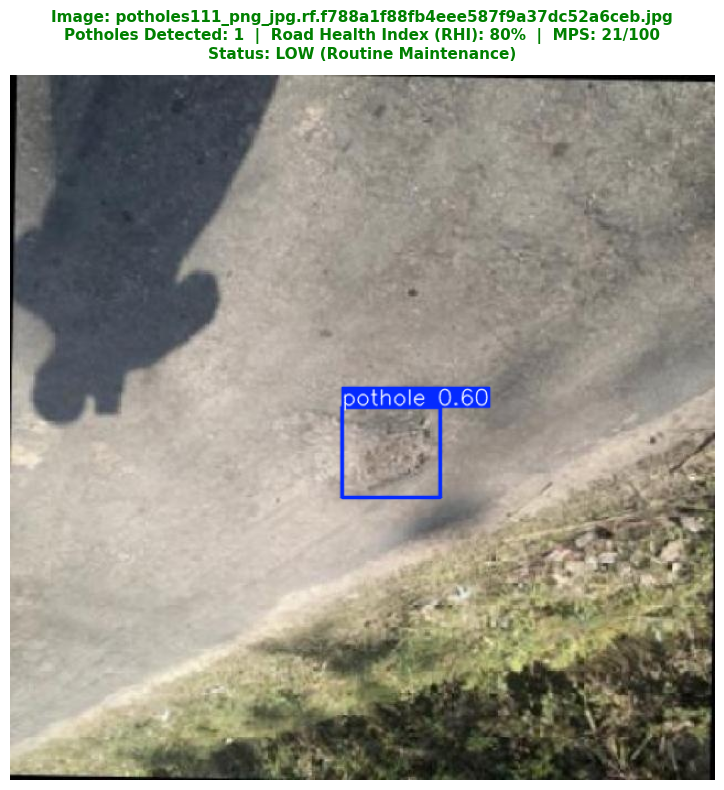

Image      : potholes111_png_jpg.rf.f788a1f88fb4eee587f9a37dc52a6ceb.jpg
Potholes   : 1
RHI        : 80%
MPS        : 21/100
Status     : LOW (Routine Maintenance)


In [32]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight   = os.path.join(latest_folder, 'weights', 'best.pt')

    if os.path.exists(best_weight):
        final_model = YOLO(best_weight)

        test_images_dir = os.path.join(pothole_dir, 'test', 'images')
        all_test_images = [f for f in os.listdir(test_images_dir) if f.endswith('.jpg')]
        random_image    = random.choice(all_test_images)
        sample_path     = os.path.join(test_images_dir, random_image)

        # Predict — conf=0.40 filters out weak/false detections
        predictions = final_model(sample_path, conf=0.40, iou=0.45, verbose=False)

        for result in predictions:
            img_bgr = result.plot(conf=True, line_width=2)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            num_potholes        = len(result.boxes)
            img_h, img_w        = result.orig_shape
            frame_area          = img_w * img_h

            # ── Road Health Index (RHI) ──────────────────────────────
            deduction_per_pothole = 20
            rhi_score = max(0, 100 - (num_potholes * deduction_per_pothole))

            # ── Maintenance Priority Score (MPS) ─────────────────────
            total_severity_score = 0

            if num_potholes > 0:
                for box in result.boxes:
                    w_box      = box.xywh[0][2].item()
                    h_box      = box.xywh[0][3].item()
                    conf_score = box.conf[0].item()

                    # Area relative to frame (0.0 – 1.0)
                    box_area_ratio = (w_box * h_box) / frame_area

                    if box_area_ratio > 0.05:
                        severity_weight = 3.0   # Large  (>5 % of frame)
                    elif box_area_ratio > 0.01:
                        severity_weight = 2.0   # Medium (1–5 % of frame)
                    else:
                        severity_weight = 1.0   # Small  (<1 % of frame)

                    total_severity_score += box_area_ratio * 100 * severity_weight * conf_score

            mps_score = min(100, int(total_severity_score * 10))

            # ── Priority Status ──────────────────────────────────────
            if mps_score >= 70 or rhi_score <= 40:
                priority_status = "CRITICAL (Immediate Action Required)"
                color_text      = 'red'
            elif mps_score >= 40 or rhi_score <= 70:
                priority_status = "MEDIUM (Scheduled Repair)"
                color_text      = 'darkorange'
            else:
                priority_status = "LOW (Routine Maintenance)"
                color_text      = 'green'

            # ── Visualisation ────────────────────────────────────────
            fig, ax = plt.subplots(figsize=(12, 8))
            ax.imshow(img_rgb)
            ax.axis('off')

            title_info = (
                f"Image: {random_image}\n"
                f"Potholes Detected: {num_potholes}  |  "
                f"Road Health Index (RHI): {rhi_score}%  |  "
                f"MPS: {mps_score}/100\n"
                f"Status: {priority_status}"
            )
            ax.set_title(title_info, fontweight='bold', fontsize=11,
                         color=color_text, pad=12)
            plt.tight_layout()
            plt.show()

            print(f"Image      : {random_image}")
            print(f"Potholes   : {num_potholes}")
            print(f"RHI        : {rhi_score}%")
            print(f"MPS        : {mps_score}/100")
            print(f"Status     : {priority_status}")
    else:
        print("File weights 'best.pt' not found. Run training first.")
else:
    print("No training folder found.")

Export Model to ONNX for Node.js

In [17]:
print("=== Export Model to ONNX Format for Node.js ===")

folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight   = os.path.join(latest_folder, 'weights', 'best.pt')

    if os.path.exists(best_weight):
        export_model = YOLO(best_weight)

        export_model.export(
            format='onnx',
            imgsz=640,
            simplify=True,
            opset=12,
            dynamic=False
        )

        onnx_path = best_weight.replace('best.pt', 'best.onnx')
        print(f"\nFile Path : {onnx_path}")
        print(f"File Size : {os.path.getsize(onnx_path) / 1024 / 1024:.1f} MB")
        print("\n=== Model Spec for Node.js Backend ===")
        print("Format  : ONNX (opset 12)")
        print("Input   : [1, 3, 640, 640]  — RGB, 640x640 px")
        print("Output  : [1, 5, 8400]")
        print("Class   : pothole (index 0)")
        print("Install : npm install onnxruntime-node")
    else:
        print("best.pt not found. Run training first.")
else:
    print("No training folder found.")

=== Export Model to ONNX Format for Node.js ===
Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CPU (13th Gen Intel Core i7-13620H)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs\detect\yolov8_pothole_kel7\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (49.6 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.7s, saved as 'runs\detect\yolov8_pothole_kel7\weights\best.onnx' (98.8 MB)

Export complete (2.3s)
Results saved to D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\runs\detect\yolov8_pothole_kel7\weights\best.onnx
Predict:         yolo predict task=detect model=runs\detect\yolov8_pothole_kel7\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\yolov8_pothole_kel7\weights\best.onnx imgsz=640 data=d:\Albert\Binus\Kuliah Semester 4\Computer Visi